# Projeto Guiado — Parte 1 (Semana 14)
### Prevendo mercados de apostas esportivas com estatísticas do minuto 60 (dados InPlayGuru)

**Grupo 9 — Tema 4 | Grupo de Estudo de Machine Learning – Panda UFSCar 2026**

## 1. Introdução

Escolhi esse tema porque curto futebol e queria testar se dá pra usar só o que já aconteceu no jogo até um certo minuto pra prever como ele termina — sem depender de odds nem de nada que só se sabe depois.

**O que eu quero prever (y):** defini 3 alvos binários, todos calculados a partir do resultado no Tempo Cheio (FT):
- `y_over25` — o jogo termina com mais de 2.5 gols?
- `y_btts` — os dois times marcam pelo menos 1 gol (Ambas Marcam)?
- `y_over95corners` — o jogo termina com mais de 9.5 escanteios?

Nessa Parte 1 eu foquei no **`y_over25`**, que é o mais intuitivo pra validar se a ideia funciona. Os outros dois já ficam prontos no dataframe pra eu usar na Parte 2.

**O que eu tenho pra usar (X):** estatísticas do jogo registradas no minuto 60 e no intervalo (45'): placar, escanteios, finalizações, ataques, posse de bola, cartões, pênaltis, além da posição das equipes na tabela, região e liga.

**De onde vêm os dados:** peguei um export da plataforma InPlayGuru, que registra alertas gerados automaticamente no minuto 60 de partidas de ligas europeias, junto com o resultado final de cada jogo.

**Minha hipótese antes de olhar os dados:** acho que estatísticas de "intensidade ofensiva" até o minuto 60 (finalizações, ataques, posse, escanteios) devem ter alguma relação com a chance de sair mais gol ou mais escanteio depois disso — mas quero confirmar isso na EDA antes de sair modelando.

**Como rodar:** é só ir executando célula por célula (Shift+Enter). Lá na frente vai pedir pra eu subir o arquivo `InPlayGuru_Europa_minuto_60.xlsx`.

**O que entra nessa entrega (Semana 14):** EDA, pré-processamento e uma baseline simples. Testar vários modelos, comparar e otimizar fica pra Parte 2 (Semana 15), conforme o enunciado.

## 0. Instalando o que vou usar

In [1]:
!pip install -q scikit-learn openpyxl matplotlib seaborn pandas numpy

## 1. Subindo os dados
Executa a célula de baixo e seleciona o arquivo `InPlayGuru_Europa_minuto_60.xlsx`.

In [2]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import files
    print("Selecione o arquivo InPlayGuru_Europa_minuto_60.xlsx")
    uploaded = files.upload()
    FILE_PATH = list(uploaded.keys())[0]
else:
    # Rodando fora do Colab: ajusto o caminho na mão
    FILE_PATH = "InPlayGuru_Europa_minuto_60.xlsx"

print("Arquivo usado:", FILE_PATH)

# Alternativa via Google Drive (se eu quiser evitar re-upload toda vez):
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = "/content/drive/MyDrive/caminho/para/InPlayGuru_Europa_minuto_60.xlsx"


Selecione o arquivo InPlayGuru_Europa_minuto_60.xlsx


Saving InPlayGuru_Europa minuto 60.xlsx to InPlayGuru_Europa minuto 60.xlsx
Arquivo usado: InPlayGuru_Europa minuto 60.xlsx


## 2. Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (7, 5)
sns.set_style("whitegrid")


## 3. Primeira olhada nos dados
O cabeçalho de verdade da planilha está na **segunda linha** (`header=1`) — a primeira linha só agrupa os blocos de colunas (tipo "Home", "Away", "HT").

In [4]:
df = pd.read_excel(FILE_PATH, header=1)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Linhas:", len(df))
print("Colunas:", df.shape[1])
print("Período:", df["Date"].min(), "a", df["Date"].max())
print("Ligas:", df["League"].nunique(), "| Regiões:", df["Region"].nunique())
df.head()


Linhas: 55346
Colunas: 119
Período: 2023-03-04 19:15:53 a 2025-12-22 17:22:36
Ligas: 78 | Regiões: 33


,Date,Timer,Strike,Region,League,Home,Away,Home Pos,Away Pos,H Score,A Score,H Momentum,A Momentum,H xG,A xG,H SOT,A SOT,H SOFF,A SOFF,H Corners,A Corners,H Attacks,A Attacks,H Dn Attacks,A Dn Attacks,H Poss %,A Poss %,H Y Cards,A Y Cards,H R Cards,A R Cards,H Penalties,A Penalties,H Score.1,A Score.1,H Momentum.1,A Momentum.1,H xG.1,A xG.1,H SOT.1,A SOT.1,H SOFF.1,A SOFF.1,H Corners.1,A Corners.1,H Attacks.1,A Attacks.1,H Dn Attacks.1,A Dn Attacks.1,H Poss %.1,A Poss %.1,H Y Cards.1,A Y Cards.1,H R Cards.1,A R Cards.1,H Penalties.1,A Penalties.1,H Score.2,A Score.2,H Momentum.2,A Momentum.2,H xG.2,A xG.2,H SOT.2,A SOT.2,H SOFF.2,A SOFF.2,H Corners.2,A Corners.2,H Attacks.2,A Attacks.2,H Dn Attacks.2,A Dn Attacks.2,H Poss %.2,A Poss %.2,H Y Cards.2,A Y Cards.2,H R Cards.2,A R Cards.2,H Penalties.2,A Penalties.2,3-Way: Home,3-Way: Draw,3-Way: Away,Over 0.5 Goals,Under 0.5 Goals,Over 1.5 Goals,Under 1.5 Goals,Over 2.5 Goals,Under 2.5 Goals,Over 3.5 Goals,Under 3.5 Goals,Over 4.5 Goals,Under 4.5 Goals,BTTS: Yes,BTTS: No,3-Way: Home.1,3-Way: Draw.1,3-Way: Away.1,Over 0.5 Goals.1,Under 0.5 Goals.1,Over 1.5 Goals.1,Under 1.5 Goals.1,Over 2.5 Goals.1,Under 2.5 Goals.1,Over 3.5 Goals.1,Under 3.5 Goals.1,Over 4.5 Goals.1,Under 4.5 Goals.1,BTTS: Yes.1,BTTS: No.1,Home.1,Away.1,Score,HT Score,FT Score,Corners,HT Corners,FT Corners
0,2023-03-04 19:15:53,60,NaN,France,France Ligue 2,Annecy,Metz,10.0,4.0,0,2,57.0,13.0,NaN,NaN,2.0,4.0,3.0,6.0,5,2,68.0,53.0,37.0,23.0,57.0,43.0,0,1,0,0,0,0,0.0,1.0,41.0,37.0,NaN,NaN,1.0,3.0,2.0,5.0,2.0,2.0,50.0,44.0,22.0,19.0,56.0,44.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,32.0,30.0,NaN,NaN,3.0,5.0,5.0,9.0,6.0,4.0,91.0,83.0,51.0,48.0,52.0,48.0,1.0,1.0,0.0,0.0,0.0,0.0,41.000,15.000,1.036,NaN,NaN,NaN,NaN,1.444,2.625,3.250,1.333,8.000,1.083,2.375,1.533,3.750,3.1,2.10,1.071,9.0,1.363,3.000,2.20,1.650,3.750,1.250,9.0,1.071,1.909,1.800,NaN,"26, 50, 82",0-2,0-1,0-3,5-2,2-2,6-4
1,2023-03-04 19:16:02,60,NaN,France,France Ligue 2,SC Bastia,Nimes,8.0,18.0,2,2,24.0,26.0,NaN,NaN,4.0,5.0,7.0,2.0,1,1,85.0,73.0,40.0,23.0,59.0,41.0,2,1,0,0,0,0,2.0,1.0,23.0,17.0,NaN,NaN,4.0,3.0,6.0,1.0,0.0,0.0,65.0,61.0,33.0,16.0,57.0,43.0,2.0,1.0,0.0,0.0,0.0,0.0,4.0,2.0,48.0,20.0,NaN,NaN,8.0,5.0,11.0,4.0,2.0,1.0,124.0,108.0,66.0,34.0,61.0,39.0,3.0,2.0,0.0,0.0,1.0,0.0,2.625,1.952,5.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.571,2.250,1.300,3.400,1.833,3.2,4.75,1.083,8.0,1.400,2.750,2.35,1.571,4.333,1.200,10.0,1.062,2.100,1.666,"27, 35, 73, 87","10, 50",2-2,2-1,4-2,1-1,0-0,2-1
2,2023-03-04 19:16:48,60,NaN,France,France Ligue 2,Niort,Rodez Aveyron,19.0,20.0,1,2,15.0,15.0,NaN,NaN,1.0,2.0,2.0,2.0,0,3,64.0,53.0,26.0,25.0,54.0,46.0,0,1,0,0,0,1,1.0,2.0,21.0,17.0,NaN,NaN,1.0,2.0,1.0,1.0,0.0,3.0,51.0,39.0,23.0,18.0,55.0,45.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,3.0,25.0,27.0,NaN,NaN,2.0,3.0,4.0,2.0,6.0,3.0,97.0,79.0,43.0,38.0,57.0,43.0,0.0,3.0,0.0,0.0,0.0,1.0,10.000,3.750,1.444,NaN,NaN,NaN,NaN,NaN,NaN,1.444,2.625,3.250,1.333,1.050,11.000,2.150,3.1,3.75,1.083,8.0,1.400,2.750,2.30,1.600,4.333,1.200,10.0,1.062,1.909,1.800,"10, 78","24, 30",1-2,1-2,2-3,0-3,0-3,6-3
3,2023-03-04 19:17:12,60,NaN,France,France Ligue 2,Paris FC,Guingamp,12.0,13.0,1,2,28.0,16.0,NaN,NaN,2.0,6.0,5.0,3.0,3,2,78.0,57.0,47.0,27.0,62.0,38.0,1,0,0,0,0,0,0.0,2.0,52.0,44.0,NaN,NaN,1.0,5.0,3.0,3.0,1.0,2.0,58.0,41.0,34.0,20.0,59.0,41.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,44.0,12.0,NaN,NaN,4.0,7.0,8.0,3.0,5.0,2.0,118.0,86.0,80.0,40.0,61.0,39.0,2.0,0.0,0.0,0.0,0.0,0.0,7.000,3.200,1.615,NaN,NaN,NaN,NaN,NaN,NaN,1.444,2.625,3.250,1.333,1.571,2.250,2.050,3.1,4.00,1.100,7.0,1.444,2.625,2.40,1.533,4.500,1.181,11.0,1.050,2.000,1.727,46,"26, 31",1-2,0-2,1-2,3-2,1-2,5-2
4,2023-03-04 19:17:49,60,NaN,France,France Ligue 2,Amiens,Pau,9.0,16.0,1,0,15.0,35.0,NaN,NaN,2.0,3.0,3.0,3.0,4,5,77.0,95.0,39.0,44.0,47.0,53.0,0,0,0,0,0,0,1.0,0.0,22.0,60.0,NaN,NaN,2.0,3.0,3.0,1.0,2.0,2.0,63.0,74.0,31.0,30.0,50.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,17.0,23.0,NaN,NaN,3.0,3.0,5.0,4.0,6.0,5.0,111.0,139.0,57.0,63.0,47.0,53.0,0.0,2.0,0.0,0.0,0.0,0.

In [5]:
# Só pra confirmar: todos os registros são realmente do minuto 60?
df["Timer"].value_counts()


,count
Timer,
60,55327
59,19


### 3.1 Tipos de dado de cada coluna

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55346 entries, 0 to 55345
Columns: 119 entries, Date to FT Corners
dtypes: datetime64[ns](1), float64(95), int64(11), object(12)
memory usage: 50.2+ MB


### 3.2 Estatísticas descritivas

In [7]:
df.describe()


,Date,Timer,Strike,Home Pos,Away Pos,H Score,A Score,H Momentum,A Momentum,H xG,A xG,H SOT,A SOT,H SOFF,A SOFF,H Corners,A Corners,H Attacks,A Attacks,H Dn Attacks,A Dn Attacks,H Poss %,A Poss %,H Y Cards,A Y Cards,H R Cards,A R Cards,H Penalties,A Penalties,H Score.1,A Score.1,H Momentum.1,A Momentum.1,H xG.1,A xG.1,H SOT.1,A SOT.1,H SOFF.1,A SOFF.1,H Corners.1,A Corners.1,H Attacks.1,A Attacks.1,H Dn Attacks.1,A Dn Attacks.1,H Poss %.1,A Poss %.1,H Y Cards.1,A Y Cards.1,H R Cards.1,A R Cards.1,H Penalties.1,A Penalties.1,H Score.2,A Score.2,H Momentum.2,A Momentum.2,H xG.2,A xG.2,H SOT.2,A SOT.2,H SOFF.2,A SOFF.2,H Corners.2,A Corners.2,H Attacks.2,A Attacks.2,H Dn Attacks.2,A Dn Attacks.2,H Poss %.2,A Poss %.2,H Y Cards.2,A Y Cards.2,H R Cards.2,A R Cards.2,H Penalties.2,A Penalties.2,3-Way: Home,3-Way: Draw,3-Way: Away,Over 0.5 Goals,Under 0.5 Goals,Over 1.5 Goals,Under 1.5 Goals,Over 2.5 Goals,Under 2.5 Goals,Over 3.5 Goals,Under 3.5 Goals,Over 4.5 Goals,Under 4.5 Goals,BTTS: Yes,BTTS: No,3-Way: Home.1,3-Way: Draw.1,3-Way: Away.1,Over 0.5 Goals.1,Under 0.5 Goals.1,Over 1.5 Goals.1,Under 1.5 Goals.1,Over 2.5 Goals.1,Under 2.5 Goals.1,Over 3.5 Goals.1,Under 3.5 Goals.1,Over 4.5 Goals.1,Under 4.5 Goals.1,BTTS: Yes.1,BTTS: No.1
count,55346,55346.000000,0.0,51321.00000,51321.000000,55346.000000,55346.000000,46856.000000,46856.000000,24095.000000,24095.000000,55278.000000,55278.000000,55278.000000,55278.000000,55346.000000,55346.000000,55278.000000,55278.000000,55278.000000,55278.000000,46856.000000,46856.000000,55346.000000,55346.000000,55346.000000,55346.000000,55346.000000,55346.000000,54375.000000,54375.000000,45973.000000,45973.000000,23561.000000,23561.000000,54307.000000,54307.000000,54307.000000,54307.000000,54375.000000,54375.000000,54307.000000,54307.000000,54307.000000,54307.000000,45973.000000,45973.000000,54375.000000,54375.000000,54375.000000,54375.000000,54375.000000,54375.000000,54987.000000,54987.000000,46566.000000,46566.000000,23977.000000,23977.000000,54900.000000,54902.000000,54899.000000,54900.000000,54987.000000,54987.000000,54897.000000,54897.000000,54897.000000,54897.000000,46565.000000,46565.000000,54987.000000,54987.000000,54987.000000,54987.000000,54987.000000,54987.000000,51647.000000,51647.000000,51647.000000,9644.000000,9644.000000,25507.000000,25507.000000,39174.000000,39174.000000,44018.000000,44018.000000,40586.000000,40586.000000,38017.000000,38017.000000,55027.000000,55028.000000,55028.000000,50674.000000,50674.000000,53100.000000,53099.000000,55260.000000,55260.000000,54059.000000,54058.000000,53400.000000,53399.000000,52398.000000,52398.000000
mean,2024-07-11 07:21:01.744389888,59.999657,NaN,9.05982,8.933497,0.950258,0.770209,32.908379,29.356134,0.811052,0.648631,2.803955,2.369804,4.559137,3.850157,3.342229,2.829328,63.004052,59.357593,34.769529,30.600275,51.358204,48.641796,0.954703,1.061649,0.033697,0.040292,0.099411,0.073248,0.700984,0.566989,32.787266,28.944185,0.591370,0.470159,2.104627,1.776382,3.446646,2.897914,2.509793,2.119871,48.147974,45.388219,26.396781,23.173348,51.422139,48.577861,0.658703,0.735834,0.021720,0.025766,0.072202,0.053352,1.555022,1.269955,33.204785,30.033028,1.347966,1.092537,4.555373,3.860843,7.347019,6.265319,5.275883,4.505938,96.836967,91.818169,55.250651,49.142995,51.190744,48.809256,1.973776,2.160711,0.087621,0.103461,0.169167,0.128812,7.940833,7.536449,13.593429,1.486884,2.660865,2.128180,2.304905,3.793597,1.885269,6.610226,1.555895,9.935342,1.336798,3.287904,1.650049,2.640052,3.933344,3.928467,1.049227,11.702732,1.266454,4.089935,1.838983,2.132246,3.096455,1.445447,5.998150,1.173605,1.821447,1.996758
min,2023-03-04 19:15:53,59.000000,NaN,1.00000,1.000000,0.000000,0.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.

### 3.3 Tem valor nulo?

In [8]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Colunas com nulo:", len(nulos))
nulos


Colunas com nulo: 97


,0
Strike,55346
Over 0.5 Goals,45702
Under 0.5 Goals,45702
H xG.1,31785
A xG.1,31785
...,...
A SOFF,68
A Attacks,68
H Attacks,68
A Dn Attacks,68


In [9]:
# E linha duplicada?
print("Linhas duplicadas:", df.duplicated().sum())


Linhas duplicadas: 0


## 4. Explorando visualmente


### 4.1 Como se distribuem as finalizações no gol até o minuto 60

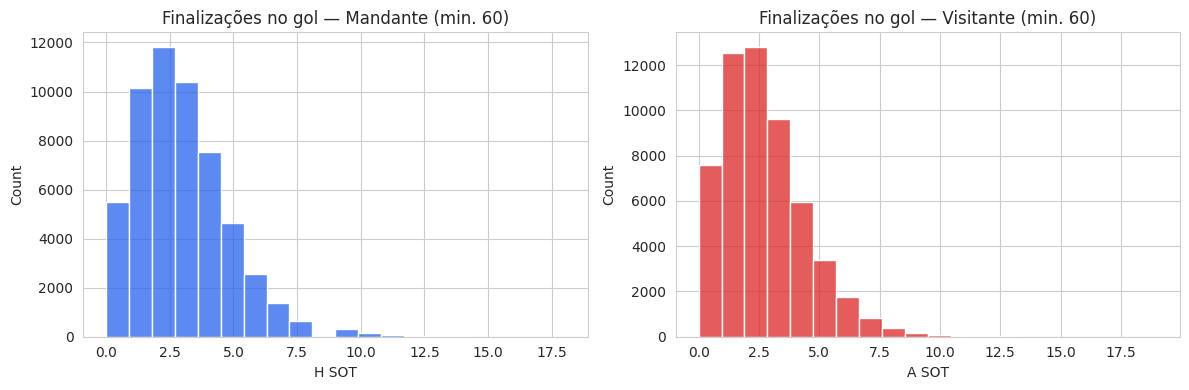

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["H SOT"], bins=20, ax=axes[0], color="#2563eb")
axes[0].set_title("Finalizações no gol — Mandante (min. 60)")
sns.histplot(df["A SOT"], bins=20, ax=axes[1], color="#dc2626")
axes[1].set_title("Finalizações no gol — Visitante (min. 60)")
plt.tight_layout()
plt.show()


### 4.2 Posse de bola por região (top 8 em número de jogos)

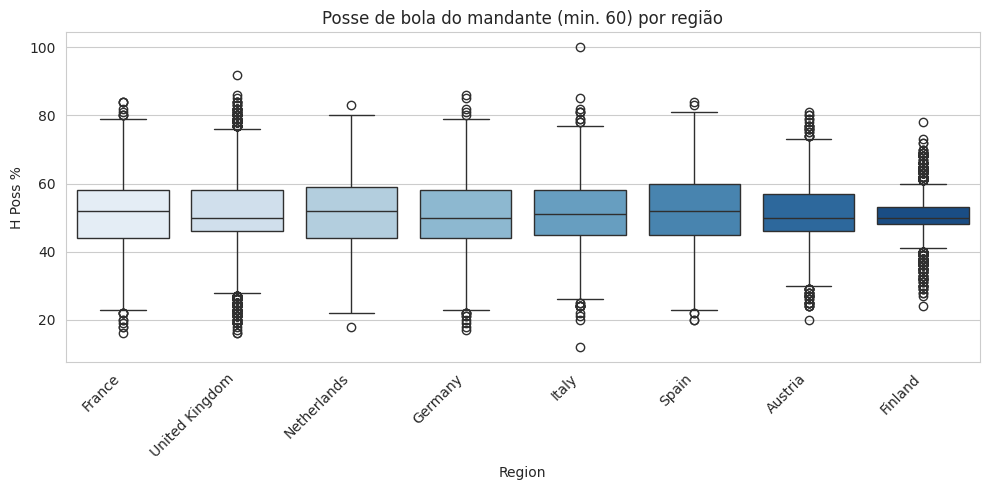

In [12]:
top8 = df["Region"].value_counts().nlargest(8).index
sub = df[df["Region"].isin(top8)]

plt.figure(figsize=(10, 5))
sns.boxplot(x="Region", y="H Poss %", data=sub, palette="Blues")
plt.title("Posse de bola do mandante (min. 60) por região")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 4.3 Correlação entre as principais estatísticas do minuto 60

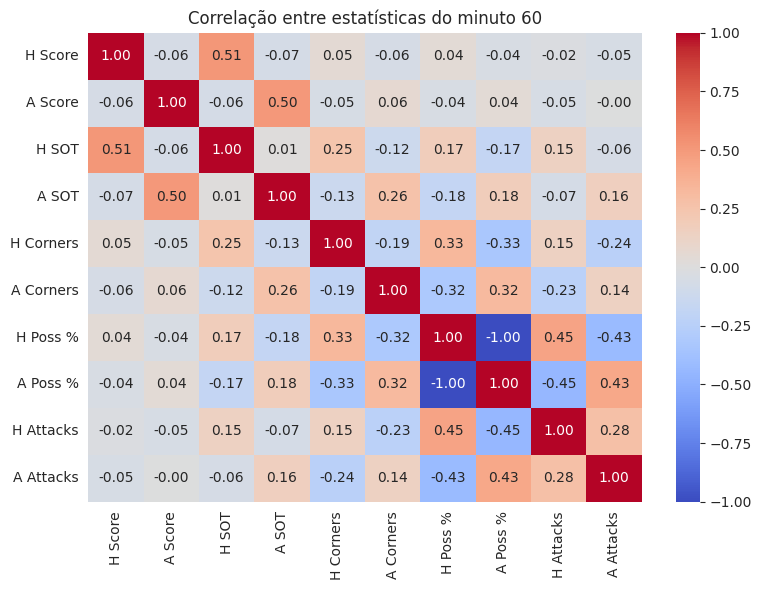

In [13]:
cols_corr = ["H Score", "A Score", "H SOT", "A SOT", "H Corners", "A Corners",
             "H Poss %", "A Poss %", "H Attacks", "A Attacks"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre estatísticas do minuto 60")
plt.tight_layout()
plt.show()


### 4.4 E a variável alvo, como se comporta?

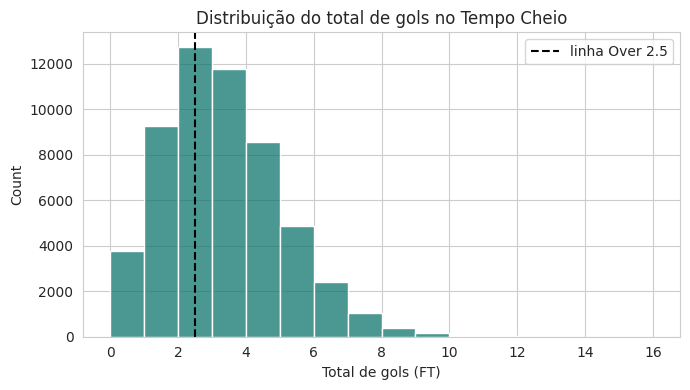

Taxa Over 2.5 Gols: 52.8%


In [14]:
FT_total_goals = df["H Score.2"] + df["A Score.2"]

plt.figure(figsize=(7, 4))
sns.histplot(FT_total_goals, bins=range(0, int(FT_total_goals.max()) + 2), color="#0f766e")
plt.axvline(2.5, color="black", linestyle="--", label="linha Over 2.5")
plt.title("Distribuição do total de gols no Tempo Cheio")
plt.xlabel("Total de gols (FT)")
plt.legend()
plt.tight_layout()
plt.show()

print("Taxa Over 2.5 Gols: %.1f%%" % ((FT_total_goals > 2.5).mean() * 100))


### 4.5 O que eu percebi olhando os gráficos e as tabelas

1. **Os nulos parecem concentrados em poucas colunas**, não espalhados pelo dataset inteiro — dá pra imputar (mediana, por exemplo) sem precisar jogar fora um monte de linha.
2. **As variáveis de contagem (finalizações, escanteios, ataques) são bem assimétricas**, com cauda longa pra direita — tem uns jogos bem "aloprados" com valor muito acima da média. Isso é bom eu lembrar na hora de escalonar e também explica por que a mediana conta mais que a média aqui.
3. **Estatísticas ofensivas parecem correlacionadas entre si** (finalização, ataque e escanteio andando juntos) — faz sentido, time que ataca mais tende a fazer as três coisas. Isso é um sinal de que vou ter feature meio redundante, o que pode importar mais pra frente quando for escolher modelo.
4. **O alvo não parece super desbalanceado** — a taxa de Over 2.5 não fica nem muito perto de 0% nem de 100%. Isso é importante porque, se fosse muito desbalanceado, uma baseline boba (tipo "sempre prever não-Over") já teria acurácia alta e ficaria difícil saber se meu modelo está realmente aprendendo algo.

## 5. Montando as variáveis que quero prever (targets)
Os 3 alvos usam só as colunas de **Tempo Cheio (FT)** — que na planilha têm o sufixo `.2`.

In [15]:
df["FT_total_goals"] = df["H Score.2"] + df["A Score.2"]
df["FT_total_corners"] = df["H Corners.2"] + df["A Corners.2"]

df["y_over25"] = (df["FT_total_goals"] > 2.5).astype(int)
df["y_btts"] = ((df["H Score.2"] > 0) & (df["A Score.2"] > 0)).astype(int)
df["y_over95corners"] = (df["FT_total_corners"] > 9.5).astype(int)

print("Taxa Over 2.5 Gols:      %.1f%%" % (df["y_over25"].mean() * 100))
print("Taxa Ambas Marcam:       %.1f%%" % (df["y_btts"].mean() * 100))
print("Taxa Over 9.5 Escanteios:%.1f%%" % (df["y_over95corners"].mean() * 100))


Taxa Over 2.5 Gols:      52.8%
Taxa Ambas Marcam:       53.1%
Taxa Over 9.5 Escanteios:50.2%


## 6. Criando as features

- colunas sem sufixo = estatística no minuto do alerta (60')
- colunas `.1` = estatística no intervalo (45') — já aconteceu, então pode usar
- **nunca** usar as colunas `.2` (Tempo Cheio), nem minuto do gol, nem resumo final — isso seria "trapacear" olhando o futuro do jogo.

In [16]:
stat_bases = [
    "Score", "Momentum", "SOT", "SOFF", "Corners", "Attacks",
    "Dn Attacks", "Poss %", "Y Cards", "R Cards", "Penalties",
]
alert_cols = [f"H {b}" for b in stat_bases] + [f"A {b}" for b in stat_bases]
ht_cols = [f"{c}.1" for c in alert_cols]
feature_num_cols = alert_cols + ht_cols + ["Home Pos", "Away Pos"]

feat = df[feature_num_cols].copy()
feat.shape


(55346, 46)

In [17]:
# Umas variáveis derivadas que fazem sentido pro problema (diferença e soma entre os times)
feat["goal_diff_60"] = df["H Score"] - df["A Score"]
feat["total_goals_60"] = df["H Score"] + df["A Score"]
feat["corner_diff_60"] = df["H Corners"] - df["A Corners"]
feat["total_corners_60"] = df["H Corners"] + df["A Corners"]
feat["sot_diff_60"] = df["H SOT"] - df["A SOT"]
feat["total_sot_60"] = df["H SOT"] + df["A SOT"]
feat["momentum_diff_60"] = df["H Momentum"] - df["A Momentum"]
feat["poss_diff_60"] = df["H Poss %"] - df["A Poss %"]
feat["pos_diff"] = df["Home Pos"] - df["Away Pos"]
feat["goal_diff_HT"] = df["H Score.1"] - df["A Score.1"]
feat["goals_after_HT_to_60"] = feat["total_goals_60"] - (df["H Score.1"] + df["A Score.1"])

# Region: fiz one-hot só das 15 mais frequentes, o resto vira "Other" (senão explode em colunas)
top_regions = df["Region"].value_counts().nlargest(15).index
feat["Region_grp"] = df["Region"].where(df["Region"].isin(top_regions), "Other")
region_dummies = pd.get_dummies(feat["Region_grp"], prefix="Region")
feat = pd.concat([feat.drop(columns=["Region_grp"]), region_dummies], axis=1)

# League: usei frequency encoding em vez de one-hot porque tem liga demais
feat["League_freq"] = df["League"].map(df["League"].value_counts())

FEATURE_COLS = feat.columns.tolist()
print("Total de features:", len(FEATURE_COLS))
feat.head()


Total de features: 74


,H Score,H Momentum,H SOT,H SOFF,H Corners,H Attacks,H Dn Attacks,H Poss %,H Y Cards,H R Cards,H Penalties,A Score,A Momentum,A SOT,A SOFF,A Corners,A Attacks,A Dn Attacks,A Poss %,A Y Cards,A R Cards,A Penalties,H Score.1,H Momentum.1,H SOT.1,H SOFF.1,H Corners.1,H Attacks.1,H Dn Attacks.1,H Poss %.1,H Y Cards.1,H R Cards.1,H Penalties.1,A Score.1,A Momentum.1,A SOT.1,A SOFF.1,A Corners.1,A Attacks.1,A Dn Attacks.1,A Poss %.1,A Y Cards.1,A R Cards.1,A Penalties.1,Home Pos,Away Pos,goal_diff_60,total_goals_60,corner_diff_60,total_corners_60,sot_diff_60,total_sot_60,momentum_diff_60,poss_diff_60,pos_diff,goal_diff_HT,goals_after_HT_to_60,Region_Austria,Region_Belgium,Region_Finland,Region_France,Region_Germany,Region_Greece,Region_Hungary,Region_Italy,Region_Netherlands,Region_Norway,Region_Other,Region_Poland,Region_Portugal,Region_Spain,Region_Sweden,Region_United Kingdom,League_freq
0,0,57.0,2.0,3.0,5,68.0,37.0,57.0,0,0,0,2,13.0,4.0,6.0,2,53.0,23.0,43.0,1,0,0,0.0,41.0,1.0,2.0,2.0,50.0,22.0,56.0,0.0,0.0,0.0,1.0,37.0,3.0,5.0,2.0,44.0,19.0,44.0,0.0,0.0,0.0,10.0,4.0,-2,2,3,7,-2.0,6.0,44.0,14.0,6.0,-1.0,1.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,951
1,2,24.0,4.0,7.0,1,85.0,40.0,59.0,2,0,0,2,26.0,5.0,2.0,1,73.0,23.0,41.0,1,0,0,2.0,23.0,4.0,6.0,0.0,65.0,33.0,57.0,2.0,0.0,0.0,1.0,17.0,3.0,1.0,0.0,61.0,16.0,43.0,1.0,0.0,0.0,8.0,18.0,0,4,0,2,-1.0,9.0,-2.0,18.0,-10.0,1.0,1.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,951
2,1,15.0,1.0,2.0,0,64.0,26.0,54.0,0,0,0,2,15.0,2.0,2.0,3,53.0,25.0,46.0,1,0,1,1.0,21.0,1.0,1.0,0.0,51.0,23.0,55.0,0.0,0.0,0.0,2.0,17.0,2.0,1.0,3.0,39.0,18.0,45.0,1.0,0.0,1.0,19.0,20.0,-1,3,-3,3,-1.0,3.0,0.0,8.0,-1.0,-1.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,951
3,1,28.0,2.0,5.0,3,78.0,47.0,62.0,1,0,0,2,16.0,6.0,3.0,2,57.0,27.0,38.0,0,0,0,0.0,52.0,1.0,3.0,1.0,58.0,34.0,59.0,1.0,0.0,0.0,2.0,44.0,5.0,3.0,2.0,41.0,20.0,41.0,0.0,0.0,0.0,12.0,13.0,-1,3,1,5,-4.0,8.0,12.0,24.0,-1.0,-2.0,1.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,951
4,1,15.0,2.0,3.0,4,77.0,39.0,47.0,0,0,0,0,35.0,3.0,3.0,5,95.0,44.0,53.0,0,0,0,1.0,22.0,2.0,3.0,2.0,63.0,31.0,50.0,0.0,0.0,0.0,0.0,60.0,3.0,1.0,2.0,74.0,30.0,50.0,0.0,0.0,0.0,9.0,16.0,1,1,-1,9,-1.0,5.0,-20.0,-6.0,-7.0,1.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,951


## 7. Pré-processamento
Regra que tentei seguir o tempo todo: **o que eu aplico no treino, aplico do mesmo jeito no teste** (usando os parâmetros aprendidos só no treino).

- **Nulos:** imputação pela mediana (`SimpleImputer`), dentro do `Pipeline` — assim ele "aprende" a mediana só olhando o treino.
- **Escalonamento:** `StandardScaler`, porque as variáveis estão em escalas bem diferentes (posse em % vs. contagem de escanteio, por exemplo).
- **Categóricas:** `Region` em one-hot e `League` em frequency encoding (já fiz isso lá na seção 6).
- **Split treino/teste:** fiz **temporal** e não aleatório — jogos mais antigos viram treino, os mais recentes viram teste. Achei que fazia mais sentido assim, já que na prática eu ia usar o modelo pra prever jogo futuro, não jogo aleatório do passado.

In [18]:
split_idx = int(len(df) * 0.75)
split_date = df["Date"].iloc[split_idx]
print("Data de corte treino/teste:", split_date)

train_mask = df.index < split_idx
test_mask = ~train_mask

print("Linhas treino:", train_mask.sum(), "| Linhas teste:", test_mask.sum())


Data de corte treino/teste: 2025-03-28 18:16:46
Linhas treino: 41509 | Linhas teste: 13837


## 8. Baseline
Modelo simples de referência: **Regressão Logística**, sem mexer em hiperparâmetro, treinado pro alvo principal `y_over25`. O pré-processamento (imputação + escalonamento) fica dentro do `Pipeline`, então é aprendido só no treino e aplicado igual no teste — sem "vazar" informação.

In [19]:
TARGET = "y_over25"

y = df[TARGET]
valid = feat.notna().any(axis=1) & y.notna()

X_train, y_train = feat[train_mask & valid], y[train_mask & valid]
X_test, y_test = feat[test_mask & valid], y[test_mask & valid]

baseline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
baseline.fit(X_train, y_train)

pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test)[:, 1]

print("Baseline (Regressão Logística) — alvo:", TARGET)
print("Acurácia :", round(accuracy_score(y_test, pred), 3))
print("AUC      :", round(roc_auc_score(y_test, proba), 3))
print()
print(classification_report(y_test, pred))


Baseline (Regressão Logística) — alvo: y_over25
Acurácia : 0.814
AUC      : 0.886

              precision    recall  f1-score   support

           0       0.79      0.81      0.80      6308
           1       0.84      0.81      0.83      7529

    accuracy                           0.81     13837
   macro avg       0.81      0.81      0.81     13837
weighted avg       0.81      0.81      0.81     13837



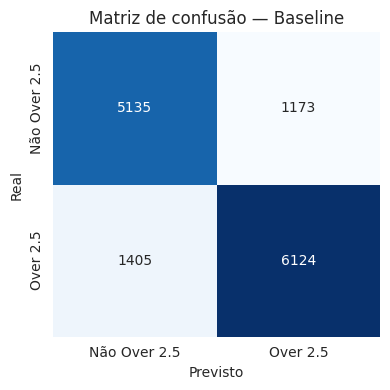

In [20]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Não Over 2.5", "Over 2.5"], yticklabels=["Não Over 2.5", "Over 2.5"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de confusão — Baseline")
plt.tight_layout()
plt.show()


In [21]:
# Baseline "boba" só pra ter uma referência mínima: sempre prever a classe mais frequente
classe_freq = y_train.mode()[0]
acc_boba = (y_test == classe_freq).mean()
print(f"Baseline boba (sempre '{classe_freq}'): acurácia = {acc_boba:.3f}")
print(f"Minha Regressão Logística: acurácia = {accuracy_score(y_test, pred):.3f}")


Baseline boba (sempre '1'): acurácia = 0.544
Minha Regressão Logística: acurácia = 0.814


## 9. Resumindo o que eu fiz

- **Dataset:** InPlayGuru, estatísticas de jogos de futebol europeu no minuto 60 (período e volume exatos aparecem na seção 3).
- **EDA:** dados relativamente limpos, nulo concentrado em poucas colunas, variáveis de contagem meio assimétricas, correlação esperada entre estatísticas ofensivas, e o alvo (`y_over25`) sem desbalanceamento muito forte.
- **Pré-processamento:** imputação por mediana, `StandardScaler`, `Region` em one-hot, `League` em frequency encoding, split treino/teste temporal (75/25).
- **Baseline:** Regressão Logística pra `y_over25`, comparada com a baseline boba de "sempre a classe mais frequente" — é meu ponto de partida pra Parte 2.

**O que fica pra Parte 2 (Semana 15):** testar outros modelos (Árvore de Decisão, Random Forest, Gradient Boosting/XGBoost), comparar as métricas, escolher o melhor e justificar, rodar `GridSearchCV` pra otimizar, e fechar a documentação do repositório.